In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import os
import pandas as pd
import cv2
import tensorflow

c:\Users\27722\anaconda3\lib\importlib\_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
c:\Users\27722\anaconda3\lib\importlib\_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


In [4]:
pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


Keyring is skipped due to an exception: 'keyring.backends'


In [5]:
train_folder = r"C:\ACML\Radiography\train"
val_folder = r"C:\ACML\Radiography\val"
test_folder = r"C:\ACML\Radiography\test"

In [6]:
labels = ["NORMAL", "PNEUMONIA"] # each folder has two sub folder name "PNEUMONIA", "NORMAL"
IMG_SIZE = 152 # resize image I will make this 152 when doing preprocessing

def get_data_train(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label) #look for subfolders N and P
        class_num = labels.index(label) #0 for NORMAL, 1 for PNEUMONIA
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)#convert to grayscale
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))#have to make this 152
                data.append([new_array, class_num])
            except Exception as e:
                print(e)
    return np.array(data, dtype=object)

In [7]:
train = get_data_train(train_folder)
test = get_data_train(test_folder)
val = get_data_train(val_folder)

OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'



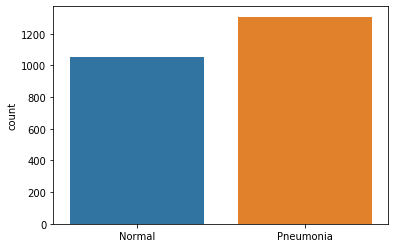

In [8]:
l = []
for i in train:
    if(i[1] == 0):
        l.append("Normal")
    else:
        l.append("Pneumonia")
        
sns.countplot(x = l) #specifically state which axis data belongs to
plt.show()

In [9]:
X_train = []
y_train = []

X_val = []
y_val = []

X_test = []
y_test = []

for feature, label in train:
    X_train.append(feature)
    y_train.append(label)

for feature, label in test:
    X_test.append(feature)
    y_test.append(label)
    
for feature, label in val:
    X_val.append(feature)
    y_val.append(label)

In [10]:
X_train = np.array(X_train) / 255.0
X_val = np.array(X_val) / 255.0
X_test = np.array(X_test) / 255.0

In [11]:
X_train.shape

(2360, 152, 152)

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, 1)#-1 shortcut telling NumPy to figure out number of images automatically
y_train = np.array(y_train)

datagen = ImageDataGenerator(
    rotation_range=20,      # Randomly rotate images (0-20 degrees)
    zoom_range=0.2,         # Randomly zoom in/out by 20%
    width_shift_range=0.1,  # Randomly shift images horizontally
    height_shift_range=0.1, # Randomly shift images vertically
    horizontal_flip=True,   # Randomly flip images (Normal lungs vs Pneumonia)
    fill_mode='nearest'     # How to fill empty pixels created by rotation/shifts
)

In [13]:
X_val = X_val.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_val = np.array(y_val)

X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y_test = np.array(y_test)

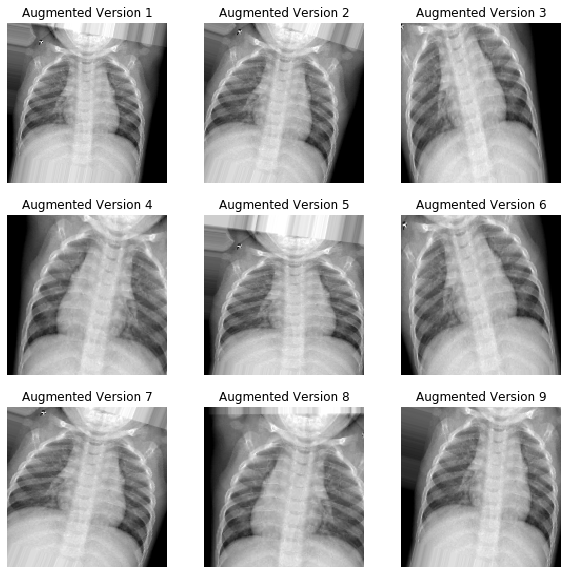

In [14]:
plt.figure(figsize=(10, 10))
# Take one image from your training set
sample_img = X_train[0].reshape((1, IMG_SIZE, IMG_SIZE, 1))

# Generate 9 random versions of this one image
i = 0
for batch in datagen.flow(sample_img, batch_size=1):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title(f"Augmented Version {i+1}")
    plt.axis('off')
    i += 1
    if i % 9 == 0:
        break
plt.show()

In [22]:
import tensorflow as tf
from tensorflow.keras.layers import Flatten, Conv2D, Activation, Dense, Dropout, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

In [16]:
X_train.shape

(2360, 152, 152, 1)

In [ ]:
model = Sequential()

# Block 1 - 32 filters
model.add(Conv2D(32, (3, 3), padding="same", input_shape=X_train.shape[1:]))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))

# Block 2 - Increase to 64 filters
model.add(Conv2D(64, (3, 3), padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))

# Block 3 - Increase to 128 filters
model.add(Conv2D(128, (3, 3), padding="same"))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling2D(2, 2))

# Transition to Dense
model.add(GlobalAveragePooling2D()) # Replaces Flatten()
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(Dropout(0.3)) # Slightly higher dropout for the final push

model.add(Dense(1, activation="sigmoid"))

# Compile with your specific learning rate
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

early_stop   = tf.keras.callbacks.EarlyStopping(monitor='loss', 
                                            patience=3,
                                            restore_best_weights=True)


# Train using the data generator
batch_size = 32

history = model.fit(
    X_train,
    y_train, 
    epochs=15, 
    batch_size=32, 
    validation_data=(X_val, y_val), 
    shuffle=True, 
    callbacks=[early_stop]
)       
          

Epoch 1/15


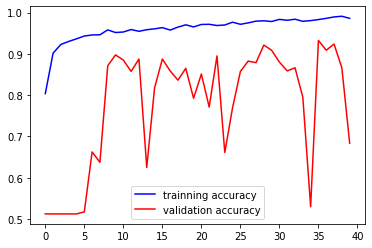

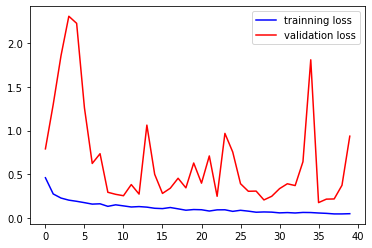

In [26]:
import matplotlib.pyplot as plt
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, "b", label="trainning accuracy")
plt.plot(epochs, val_accuracy, "r", label="validation accuracy")
plt.legend()
plt.show()

plt.plot(epochs, loss, "b", label="trainning loss")
plt.plot(epochs, val_loss, "r", label="validation loss")
plt.legend()
plt.show()